In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.neighbors import LocalOutlierFactor

import missingno as msno
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
# use auto



In [2]:
def load_datasets(base_path='../data/phase_1/', na_value='-999.25'):
    """
    Load training and test datasets from specified path.
    
    Parameters:
    -----------
    base_path : str, default '../data/phase_1/'
        Base directory path where the datasets are located
    na_value : str or float, default '-999.25'
        Value to be treated as NaN in the training datasets
    
    Returns:
    --------
    dict : Dictionary containing training and test dataframes
        Keys: 'train_1', 'train_2', 'train_3', 'test_1', 'test_2', 'test_3'
    """
    # Initialize dictionary to store dataframes
    datasets = {}
    
    # Load training datasets
    for i in range(1, 4):
        train_path = f"{base_path}Training_dataset_{i}.csv"
        datasets[f'train_{i}'] = pd.read_csv(train_path, na_values=[na_value])
    
    # Load test datasets
    for i in range(1, 4):
        test_path = f"{base_path}Test_dataset_{i}.csv"
        datasets[f'test_{i}'] = pd.read_csv(test_path)
    
    return datasets



In [3]:
data = load_datasets()

# Access individual datasets
df1_train = data['train_1']
df2_train = data['train_2']
df3_train = data['train_3']
df1_test = data['test_1']
df2_test = data['test_2']
df3_test = data['test_3']


In [4]:

def debug_missing_data(df, threshold=20):
    """
    Debug missing data analysis for numerical columns with detailed shape information at each step.
    
    Parameters:
    df (pandas.DataFrame): Input DataFrame
    threshold (float): Max percentage of missing values allowed
    
    Returns:
    pandas.DataFrame: Imputed DataFrame with only numerical columns, or None if process fails
    """
    # Step 1: Select only numeric columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    df_numeric = df[numeric_cols].copy()
    
    print("Step 1: Initial DataFrame Info")
    print(f"Original DataFrame shape: {df.shape}")
    print(f"Numeric-only DataFrame shape: {df_numeric.shape}")
    print("\nNumeric columns selected:")
    print(df_numeric.columns.tolist())
    
    # Step 2: Calculate missing percentages for numeric columns
    missing_percentage = df_numeric.isnull().sum() / len(df_numeric) * 100
    missing_df = pd.DataFrame({
        'Column': missing_percentage.index,
        'Missing Percentage': missing_percentage.values
    }).sort_values('Missing Percentage', ascending=False)
    
    print("\nStep 2: Missing Value Analysis (Numeric Columns Only)")
    print(missing_df)
    
    # Step 3: Filter columns with missing data below threshold
    cols_with_missing = missing_df[missing_df['Missing Percentage'] < threshold]['Column'].tolist()
    print(f"\nStep 3: Numeric columns with <{threshold}% missing values:")
    print(cols_with_missing)
    
    
    # Step 3.1: Filter columns with missing data below threshold
    cols_with_missing1 = missing_df[missing_df['Missing Percentage'] > threshold]['Column'].tolist()
    print(f"\nStep 3.1: Numeric columns with >{threshold}% missing values:")
    print(cols_with_missing1)
    
    if len(cols_with_missing) > 0:
        # Step 4: Prepare data for imputation
        df_to_impute = df_numeric[cols_with_missing].copy()
        print("\nStep 4: Pre-imputation Data Check")
        print(f"Shape of data to be imputed: {df_to_impute.shape}")
        print("\nColumns to be imputed:")
        print(df_to_impute.columns.tolist())
        
        # Step 5: Check data types
        print("\nStep 5: Data Types Check")
        print(df_to_impute.dtypes)
        
        # Step 6: Attempt imputation
        print("\nStep 6: Attempting Imputation")
        try:
            imputer = KNNImputer()
            print("Starting imputer...")
            df_filled_array = imputer.fit_transform(df_to_impute)
            print("Imputation completed")
            print(f"Shape of training data: {df_to_impute.shape}")
            print(f"Shape of imputed array: {df_filled_array.shape}")
            
            # Create DataFrame from imputed values
            df_filled = pd.DataFrame(df_filled_array, columns=df_to_impute.columns)
            print(f"Shape of final DataFrame: {df_filled.shape}")
            
            # Verify column alignment
            print("\nColumn alignment check:")
            print("Input columns:", df_to_impute.columns.tolist())
            print("Output columns:", df_filled.columns.tolist())
            
            return df_filled
            
        except ValueError as e:
            print(f"\nError during imputation: {e}")
            return None
    else:
        print("No numeric columns with missing data found above the threshold.")
        return None

# Usage

debug_missing_data(df1_train).to_csv('../data/phase_1/training_dataset_1_imputed.csv', index=False)
debug_missing_data(df2_train).to_csv('../data/phase_1/training_dataset_2_imputed.csv', index=False)
debug_missing_data(df3_train).to_csv('../data/phase_1/training_dataset_3_imputed.csv', index=False)



Step 1: Initial DataFrame Info
Original DataFrame shape: (7879, 89)
Numeric-only DataFrame shape: (7879, 88)

Numeric columns selected:
['AD Delta-P SP (psi)', 'AD ROP SP (ft/hr)', 'AD Torque SP (kft·lbf)', 'AD WOB SP (klb)', 'Accum Trip In (bbl)', 'Accum Trip Out (bbl)', 'Annular Velocity (ft/min)', 'BHA Length (ft)', 'Bit MSE (psi)', 'Bit Position (ft)', 'Bit RPM (RPM)', 'Bit Size (in)', 'Bit Time (hr)', 'Bit Weight (klb)', 'Block Height (ft)', 'Bttm Pipe Temp (°F)', 'Casing Pressure (psi)', 'Circulating Hrs (hr)', 'Co. Man G/L (bbl)', 'Cont Az (deg)', 'Cont Inc (deg)', 'Depth of Cut (ft)', 'Depth(ft)', 'Diff Press (psi)', 'East West Horizontal (ft)', 'Flow Deviation (%)', 'Flow In Rate (galUS/min)', 'Flow Out Percent (%)', 'G/L Rate - 1 Min (bbl/min)', 'G/L Rate - 5 Min (bbl/min)', 'Gain Loss (bbl)', 'Gain Loss - Spare (bbl)', 'Gamma Depth (ft)', 'Gamma Ray (offset) (API)', 'Hole Depth (ft)', 'Hook Load (klb)', 'Lst Jnt Time (s)', 'ML Mud Temp IN (°F)', 'ML Mud Temp OUT (°F)', 'MSE 

In [70]:
df1_clean = pd.read_csv('../data/phase_1/training_dataset_1_imputed.csv')
df2_clean = pd.read_csv('../data/phase_1/training_dataset_2_imputed.csv')
df3_clean = pd.read_csv('../data/phase_1/training_dataset_3_imputed.csv')

In [86]:
common_cols = list(set(df3_clean.columns).intersection(set(df1_clean.columns)))

In [ ]:
selected_cols =\
[
'Bttm Pipe Temp (°F)',
'Depth(ft)',
'ML Mud Temp IN (°F)',
'Mud Temp In (°F)',
'Mud Temp Out (°F)',
'Run Jnt Time (s)',
'Bit MSE (psi)',
'Gain Loss (bbl)',
'Rotary Torque (A)',
'Diff Press (psi)']

In [108]:
selected_cols_imp = ['Annular Velocity (ft/min)',
 'G/L Rate - 5 Min (bbl/min)',
 'Time On Bottom (hr)',
 'Lst Jnt Time (s)',
 'Strks - Pump 1 (strokes)',
 'MSE Downhole (psi)',
 'Bit Time (hr)',
 'Cont Inc (deg)',
 'Block Height (ft)',
 'Gamma Depth (ft)',
 'AD WOB SP (klb)',
 'Casing Pressure (psi)',
 'Svy Inclination (deg)',
 'Pump SPM 1 (SPM)',
 'Co. Man G/L (bbl)',
 'Cont Az (deg)',
 'AD Torque SP (kft·lbf)',
 'Mud Temp Out (°F)',
 'Mud Temp In (°F)',
 'Svy Depth (ft)',
 'Total Trip Volume (bbl)',
 'Mud Weight In (lb/galUS)',
 'Strks - Total (strokes)',
 'Suction 2 Pit 10 (bbl)',
 'ROP - Cut Unit (ft/hr)',
 'Strks - Acc Fill (strokes)',
 'Depth(ft)',
 'Flow Out Percent (%)',
 'Top Drive Torque (kft·lbf)',
 'Strks - Pump 2 (strokes)',
 'Bit Weight (klb)',
 'Bttm Pipe Temp (°F)',
 'Accum Trip In (bbl)',
 'Mud Motor RPM (RPM)',
 'Strks - Pump 3 (strokes)',
 'Bit Size (in)',
 'Surface MSE wMotor (psi)',
 'Bit Position (ft)',
 'Depth of Cut (ft)',
 'WC Bit Weight (klb)',
 'AD Delta-P SP (psi)',
 'Mud Motor Torque (ft·lbf)',
 'Accum Trip Out (bbl)',
 'Hook Load (klb)',
 'Top Drive RPM (RPM)',
 'Bit RPM (RPM)',
 'Rotary Torque (A)',
 'Pump Pressure (psi)',
 'Bit MSE (psi)',
 'Total Rotations on DP ()',
 'Water Pit (bbl)',
 'Mud Volume (bbl)',
 'Suction 3 Pit 11 (bbl)',
 'ROP - Fast (ft/hr)',
 'ROP - Average (ft/hr)',
 'Pipe Length (ft)',
 'Pump SPM 3 (SPM)',
 'Trip Tank 2 (bbl)',
 'Strks - Fill (strokes)',
 'Flow In Rate (galUS/min)',
 'WC Torque (ft·lbf)',
 'Svy Azimuth (deg)',
 'Run Jnt Time (s)',
 'Time On Job (hr)',
 'G/L Rate - 1 Min (bbl/min)',
 'Pump SPM 2 (SPM)',
 'Flow Deviation (%)',
 'Washout Factor ()',
 'Time On Slip (s)',
 'AD ROP SP (ft/hr)',
 'Gain Loss (bbl)',
 'Pump SPM - Total (SPM)',
 'ML Mud Temp OUT (°F)',
 'Trip Tank 1 (bbl)',
 'Circulating Hrs (hr)',
 'Gain Loss - Spare (bbl)',
 'Rotary RPM (RPM)',
 'Suction 1 Pit 9 (bbl)',
 'ML Mud Temp IN (°F)',
 'Diff Press (psi)',
 'BHA Length (ft)',
 'MSE Total (psi)',
 'Trip Tank GL (bbl)',
 'Hole Depth (ft)']

In [88]:
selected_cols = common_cols

df1_clean = df1_clean[selected_cols]
df2_clean = df2_clean[selected_cols]
df3_clean = df3_clean[selected_cols]

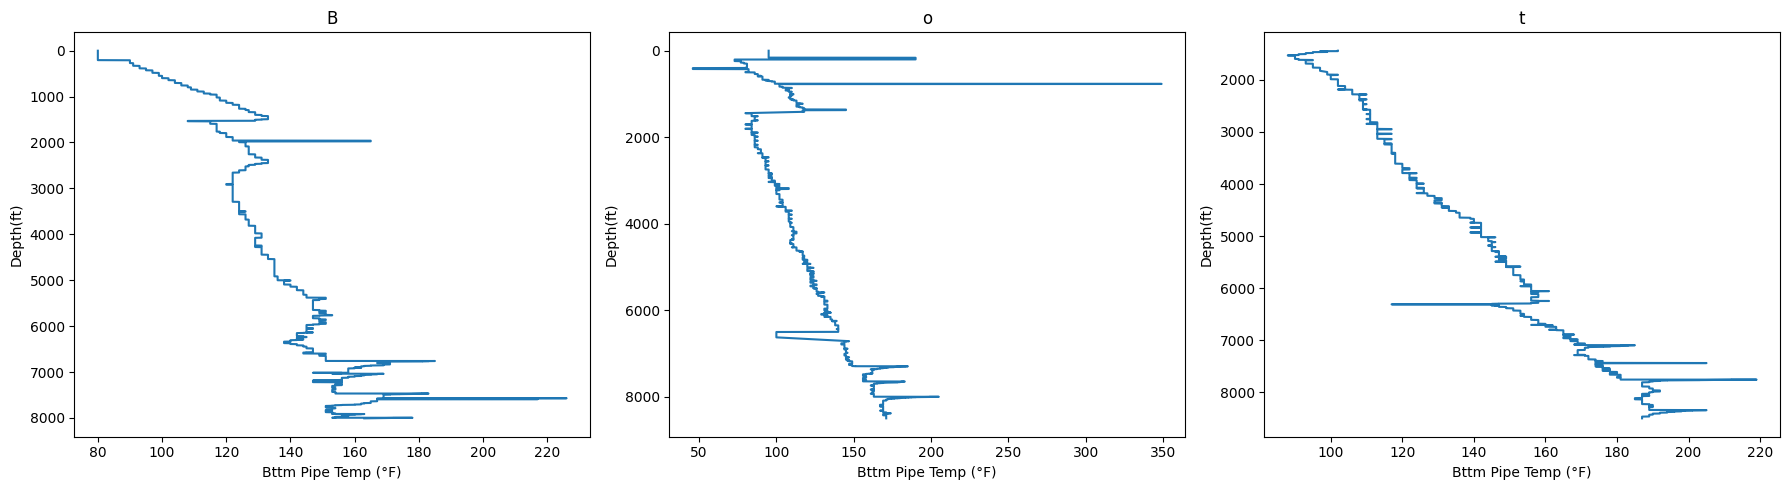

In [89]:
plot_vertical_profiles([df1_clean, df2_clean, df3_clean], 'Bttm Pipe Temp (°F)', 'Depth(ft)', 'Bottom Pipe Temperature Profile')

In [96]:
def remove_outliers_with_multiple_methods(df, methods=['zscore', 'iqr', 'isolation_forest'], columns=None):
    """
    Remove outliers using multiple methods for more robust outlier detection.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to clean
    methods : list, default ['zscore', 'iqr', 'isolation_forest']
        List of methods to use for outlier detection
    columns : list or None, default None
        Specific columns to check for outliers. If None, all numeric columns are used.
        
    Returns:
    --------
    pandas.DataFrame : Cleaned dataframe with outliers removed
    dict : Information about the removal process
    """
    import numpy as np
    import pandas as pd
    from sklearn.ensemble import IsolationForest
    from scipy import stats
    
    # Make a copy of the original dataframe
    df_clean = df.copy()
    
    # If no columns specified, use all numeric columns
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()
    
    # Track removed indices by each method
    removed_by_method = {}
    original_length = len(df)
    
    # Apply each method sequentially
    if 'zscore' in methods:
        # Z-score method (remove values beyond 3 standard deviations)
        z_scores = np.abs(stats.zscore(df_clean[columns], nan_policy='omit'))
        z_filter = (z_scores < 3).all(axis=1)
        df_clean = df_clean[z_filter]
        removed_by_method['zscore'] = original_length - len(df_clean)
    
    if 'iqr' in methods:
        # IQR method (Tukey's method)
        Q1 = df_clean[columns].quantile(0.25)
        Q3 = df_clean[columns].quantile(0.75)
        IQR = Q3 - Q1
        
        # Filter based on IQR
        iqr_filter = ~((df_clean[columns] < (Q1 - 1.5 * IQR)) | 
                      (df_clean[columns] > (Q3 + 1.5 * IQR))).any(axis=1)
        
        removed_before_iqr = len(df_clean)
        df_clean = df_clean[iqr_filter]
        removed_by_method['iqr'] = removed_before_iqr - len(df_clean)
    
    if 'isolation_forest' in methods:
        # Isolation Forest method
        iso_forest = IsolationForest(contamination=0.05, random_state=42)
        predictions = iso_forest.fit_predict(df_clean[columns])
        
        # Keep only the inliers (predictions == 1)
        removed_before_iso = len(df_clean)
        df_clean = df_clean[predictions == 1]
        removed_by_method['isolation_forest'] = removed_before_iso - len(df_clean)
    
    if 'dbscan' in methods:
        # DBSCAN clustering method
        from sklearn.cluster import DBSCAN
        from sklearn.preprocessing import StandardScaler
        
        # Scale the data first
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_clean[columns])
        
        # Apply DBSCAN
        dbscan = DBSCAN(eps=0.5, min_samples=5)
        clusters = dbscan.fit_predict(scaled_data)
        
        # Keep only non-outlier points (clusters != -1)
        removed_before_dbscan = len(df_clean)
        df_clean = df_clean[clusters != -1]
        removed_by_method['dbscan'] = removed_before_dbscan - len(df_clean)
    
    # Compile info about the removal process
    info = {
        'original_length': original_length,
        'final_length': len(df_clean),
        'total_removed': original_length - len(df_clean),
        'removed_by_method': removed_by_method,
        'percentage_removed': (original_length - len(df_clean)) / original_length * 100
    }
    
    return df_clean, info

In [113]:
len(selected_cols_imp)

84

In [110]:
df1_clean = remove_outliers_with_multiple_methods(df1_clean)
df2_clean = remove_outliers_with_multiple_methods(df2_clean)
df3_clean = remove_outliers_with_multiple_methods(df3_clean)

/tmp/ipykernel_1172749/890687803.py:38: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(df_clean[columns], nan_policy='omit'))


ValueError: Found array with 0 sample(s) (shape=(0, 84)) while a minimum of 1 is required by IsolationForest.

In [116]:
def filter_highly_correlated_features(df, target_column='Bttm Pipe Temp (°F)', threshold=0.4):
    """
    Identify features with correlation above a threshold (absolute value) with target column.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data
    target_column : str, default 'Bttm Pipe Temp (°F)'
        The target column to check correlations against
    threshold : float, default 0.5
        The minimum absolute correlation value to keep (0.5 = 50%)
    
    Returns:
    --------
    tuple : (DataFrame with correlation values, list of column names to keep)
    """
    import pandas as pd
    import numpy as np
    
    # Check if target column exists
    if target_column not in df.columns:
        raise ValueError(f"Target column '{target_column}' not found in dataframe")
    
    # Calculate correlation matrix
    corr_matrix = df.corr(numeric_only=True)
    
    # Get the correlation values with the target column
    target_correlations = corr_matrix[target_column].sort_values(ascending=False)
    
    # Print all correlations for review
    print("All correlations with", target_column)
    print(target_correlations)
    
    # Filter features with absolute correlation >= threshold
    highly_correlated = target_correlations[abs(target_correlations) >= threshold]
    
    # Create a DataFrame to display the results
    corr_df = pd.DataFrame({
        'Feature': highly_correlated.index,
        'Correlation': highly_correlated.values
    })
    
    # Print summary of selected features
    print(f"\nFeatures with |correlation| >= {threshold} ({threshold*100}%):")
    for feature, corr_value in zip(corr_df['Feature'], corr_df['Correlation']):
        corr_type = "positive" if corr_value > 0 else "negative"
        print(f"- {feature}: {corr_value:.4f} ({corr_type})")
    
    # Get list of columns to keep
    columns_to_keep = highly_correlated.index.tolist()
    
    return corr_df, columns_to_keep

In [117]:
corr_results, selected_columns = filter_highly_correlated_features(df)

All correlations with Bttm Pipe Temp (°F)
Bttm Pipe Temp (°F)    1.000000
Depth(ft)              0.908485
Bit MSE (psi)          0.796189
Mud Temp Out (°F)      0.675737
ML Mud Temp IN (°F)    0.627340
Mud Temp In (°F)       0.551653
Run Jnt Time (s)       0.486451
Rotary Torque (A)      0.359851
Gain Loss (bbl)        0.241817
Diff Press (psi)       0.199269
Name: Bttm Pipe Temp (°F), dtype: float64

Features with |correlation| >= 0.4 (40.0%):
- Bttm Pipe Temp (°F): 1.0000 (positive)
- Depth(ft): 0.9085 (positive)
- Bit MSE (psi): 0.7962 (positive)
- Mud Temp Out (°F): 0.6757 (positive)
- ML Mud Temp IN (°F): 0.6273 (positive)
- Mud Temp In (°F): 0.5517 (positive)
- Run Jnt Time (s): 0.4865 (positive)


In [115]:
selected_columns

['Bttm Pipe Temp (°F)',
 'Depth(ft)',
 'Bit MSE (psi)',
 'Mud Temp Out (°F)',
 'ML Mud Temp IN (°F)',
 'Mud Temp In (°F)']

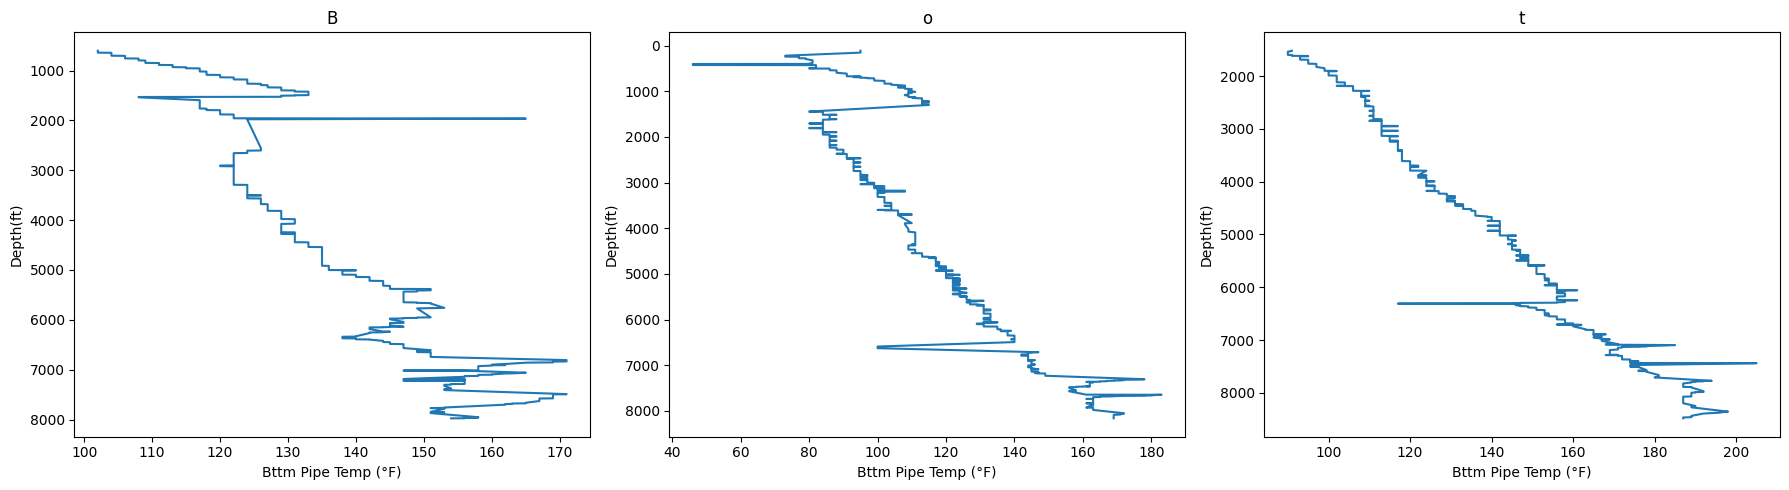

In [46]:
plot_vertical_profiles([df1_clean, df2_clean, df3_clean], 'Bttm Pipe Temp (°F)', 'Depth(ft)', 'Bottom Pipe Temperature Profile')

In [109]:
def smooth_data(df, columns=None, method='moving_avg', window=5, poly_order=2, alpha=0.3):
    """
    Smooth data using various smoothing techniques.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data to be smoothed
    columns : list or None, default None
        List of column names to smooth. If None, all numeric columns will be used.
    method : str, default 'moving_avg'
        Smoothing method to use:
        - 'moving_avg': Simple moving average
        - 'exp': Exponential moving average
        - 'savgol': Savitzky-Golay filter
        - 'lowess': Locally Weighted Scatterplot Smoothing
        - 'gaussian': Gaussian filter
    window : int, default 5
        Window size for moving averages and Savitzky-Golay filter
    poly_order : int, default 2
        Polynomial order for Savitzky-Golay filter
    alpha : float, default 0.3
        Smoothing factor for exponential moving average (0 < alpha < 1)
        Lower values = more smoothing
        
    Returns:
    --------
    pandas.DataFrame : Dataframe with smoothed data
    """
    import pandas as pd
    import numpy as np
    from scipy.signal import savgol_filter
    from scipy.ndimage import gaussian_filter1d
    
    # Make a copy of the original dataframe
    df_smoothed = df.copy()
    
    # If no columns specified, use all numeric columns
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()
    
    # Apply the selected smoothing method to each column
    for col in columns:
        # Skip columns with NaN values
        if df[col].isna().any():
            print(f"Warning: Column '{col}' contains NaN values. Skipping.")
            continue
            
        if method == 'moving_avg':
            # Simple moving average
            df_smoothed[col] = df[col].rolling(window=window, center=True).mean()
            
            # Handle NaN values at the edges
            if df_smoothed[col].isna().any():
                first_valid = df_smoothed[col].first_valid_index()
                last_valid = df_smoothed[col].last_valid_index()
                
                # Forward fill NaN values at the beginning
                if first_valid is not None and first_valid > df_smoothed.index[0]:
                    df_smoothed.loc[df_smoothed.index[0]:first_valid, col] = df_smoothed.loc[first_valid, col]
                
                # Backward fill NaN values at the end
                if last_valid is not None and last_valid < df_smoothed.index[-1]:
                    df_smoothed.loc[last_valid:df_smoothed.index[-1], col] = df_smoothed.loc[last_valid, col]
        
        elif method == 'exp':
            # Exponential moving average
            df_smoothed[col] = df[col].ewm(alpha=alpha, adjust=False).mean()
        
        elif method == 'savgol':
            # Savitzky-Golay filter
            # Window length must be odd and greater than poly_order
            if window % 2 == 0:
                window += 1
            
            # Also ensure window is greater than polynomial order
            if window <= poly_order:
                window = poly_order + 3
                
            df_smoothed[col] = savgol_filter(df[col], window, poly_order)
        
        elif method == 'lowess':
            # LOWESS (Locally Weighted Scatterplot Smoothing)
            try:
                import statsmodels.api as sm
                lowess = sm.nonparametric.lowess
                
                # Fraction of data to use for local regression
                frac = min(1.0, max(0.05, 3 * window / len(df)))
                
                # Apply LOWESS smoothing
                x = np.arange(len(df))
                y = df[col].values
                smoothed = lowess(y, x, frac=frac, it=3, return_sorted=False)
                df_smoothed[col] = smoothed
                
            except ImportError:
                print("Warning: statsmodels package not found. Using exponential smoothing instead.")
                df_smoothed[col] = df[col].ewm(alpha=alpha, adjust=False).mean()
        
        elif method == 'gaussian':
            # Gaussian filter
            sigma = window / 3  # Relation between window size and sigma
            df_smoothed[col] = gaussian_filter1d(df[col].values, sigma)
            
        else:
            print(f"Warning: Unknown smoothing method '{method}'. No smoothing applied to column '{col}'.")
    
    return df_smoothed

In [118]:
df1_clean = smooth_data(df1_clean, columns=['Bttm Pipe Temp (°F)'], method='moving_avg', window=10)
df2_clean = smooth_data(df2_clean, columns=['Bttm Pipe Temp (°F)'], method='moving_avg', window=10)
df3_clean = smooth_data(df3_clean, columns=['Bttm Pipe Temp (°F)'], method='moving_avg', window=10)

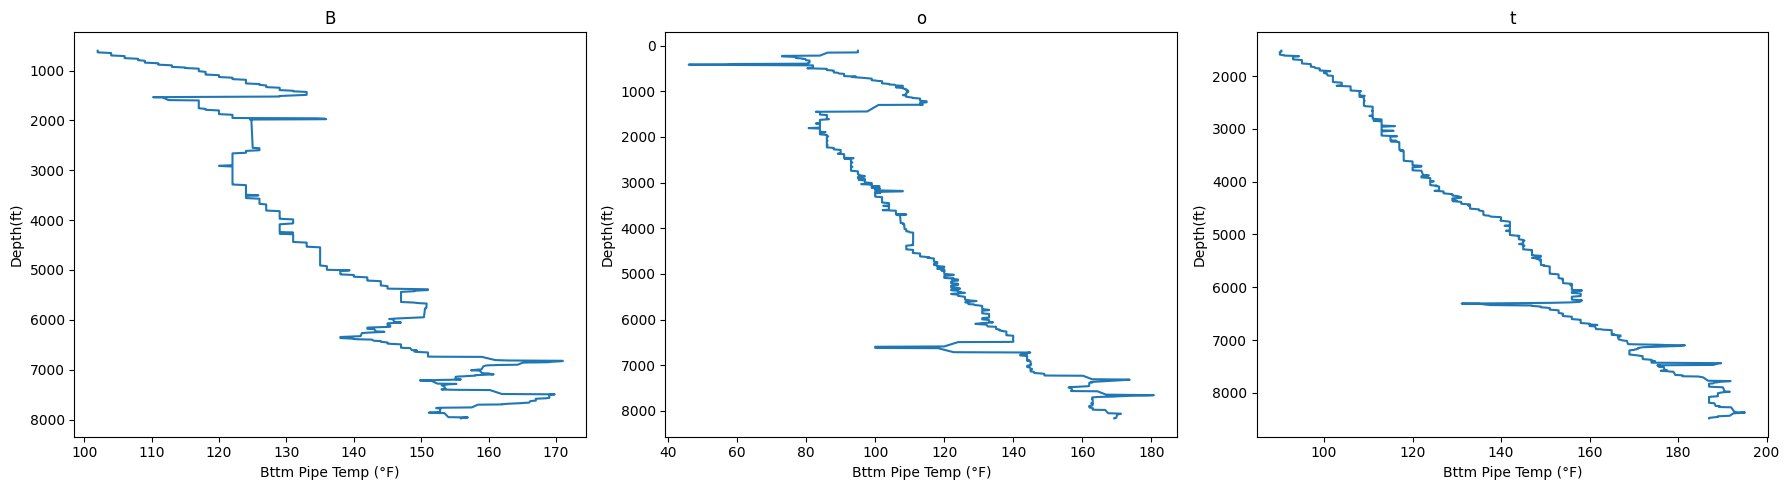

In [58]:
plot_vertical_profiles([df1_clean, df2_clean, df3_clean], 'Bttm Pipe Temp (°F)', 'Depth(ft)', 'Bottom Pipe Temperature Profile')

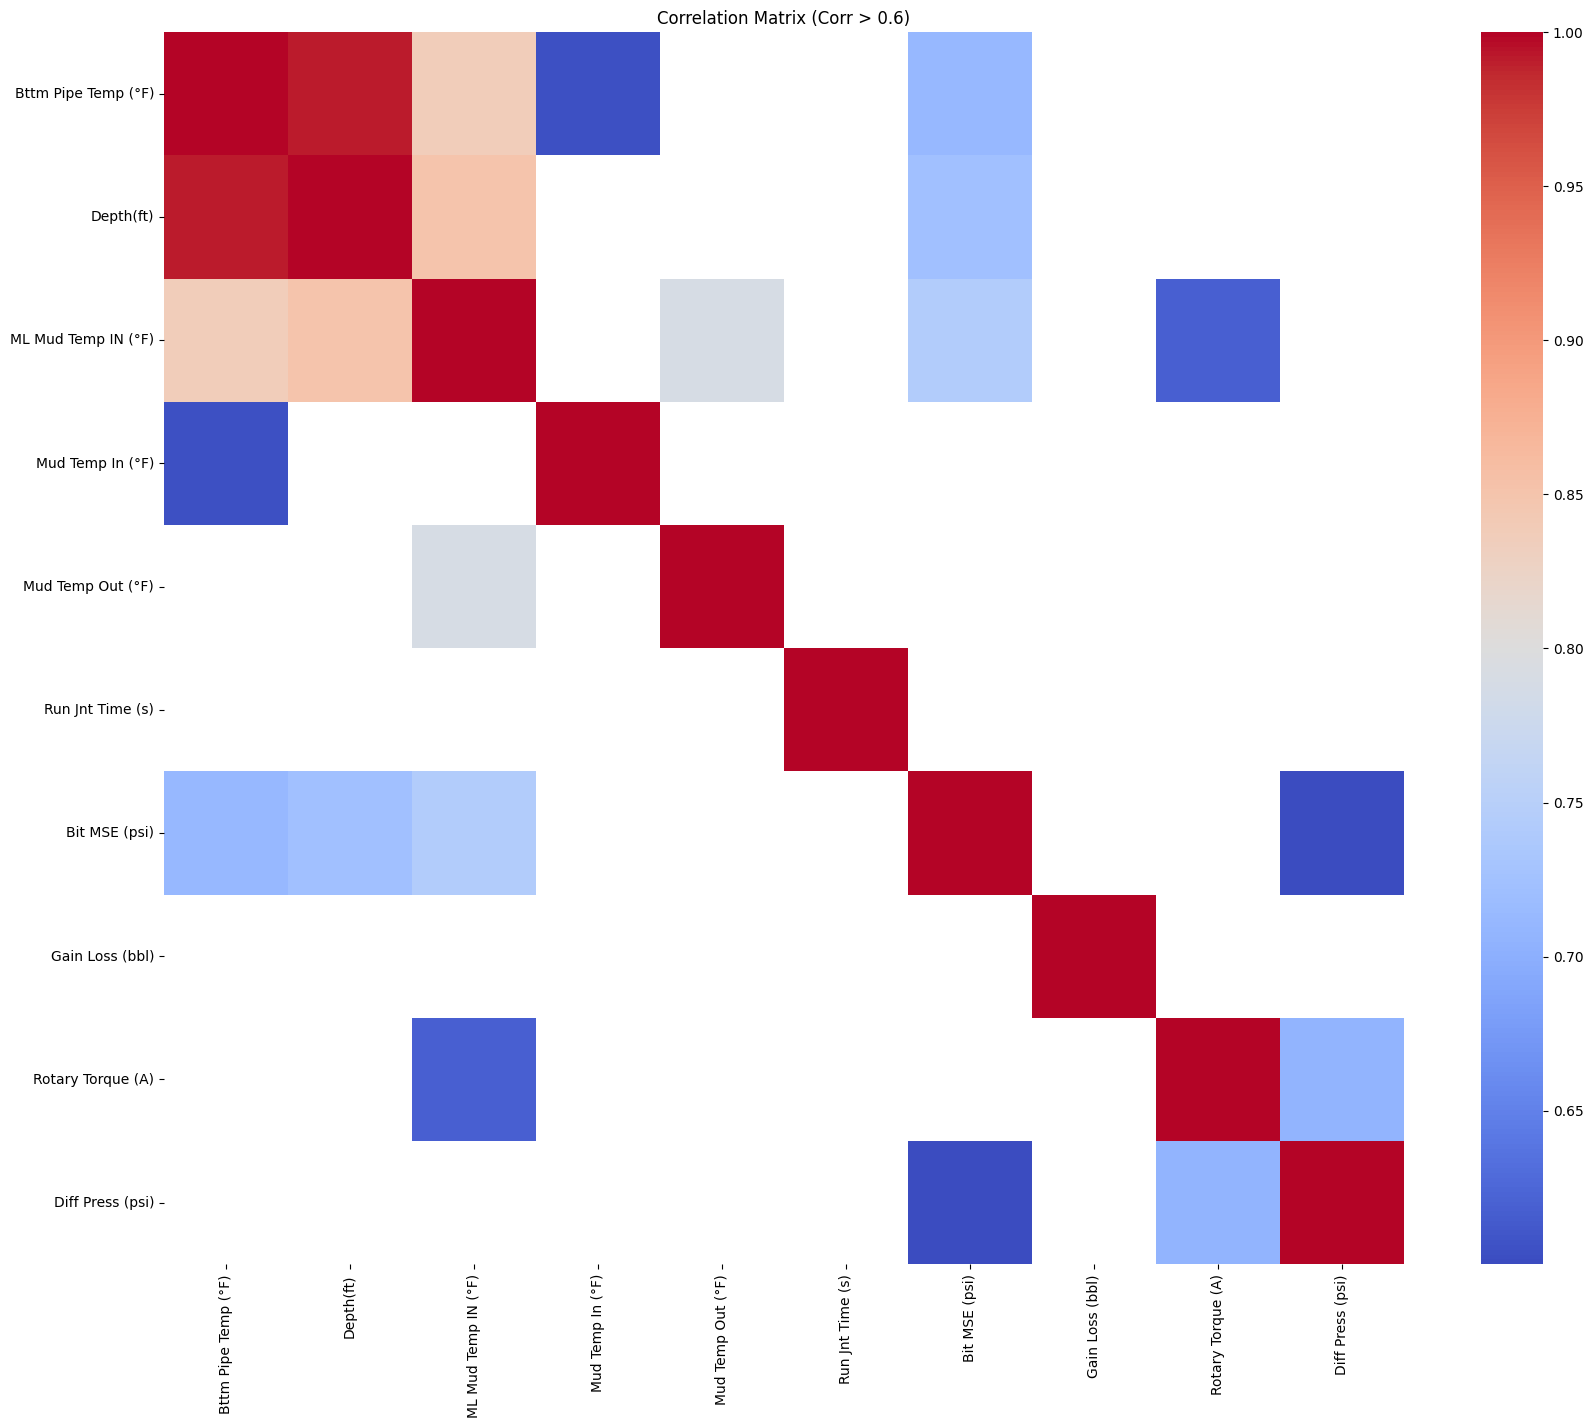

In [59]:
import seaborn as sns

# Create correlation matrix
corr = df3_clean.corr()
# Filter correlation matrix
high_corr = corr[corr>0.6]

# Plot correlation matrix heatmap



plt.figure(figsize=(20, 16))
sns.heatmap(high_corr, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix (Corr > 0.6)')
plt.show()

In [60]:
filtered_corr = corr.loc['Bttm Pipe Temp (°F)', :][corr.loc['Bttm Pipe Temp (°F)', :] > 0].sort_values(ascending=False)

In [62]:
positive_corrs_cols = filtered_corr.index.tolist()

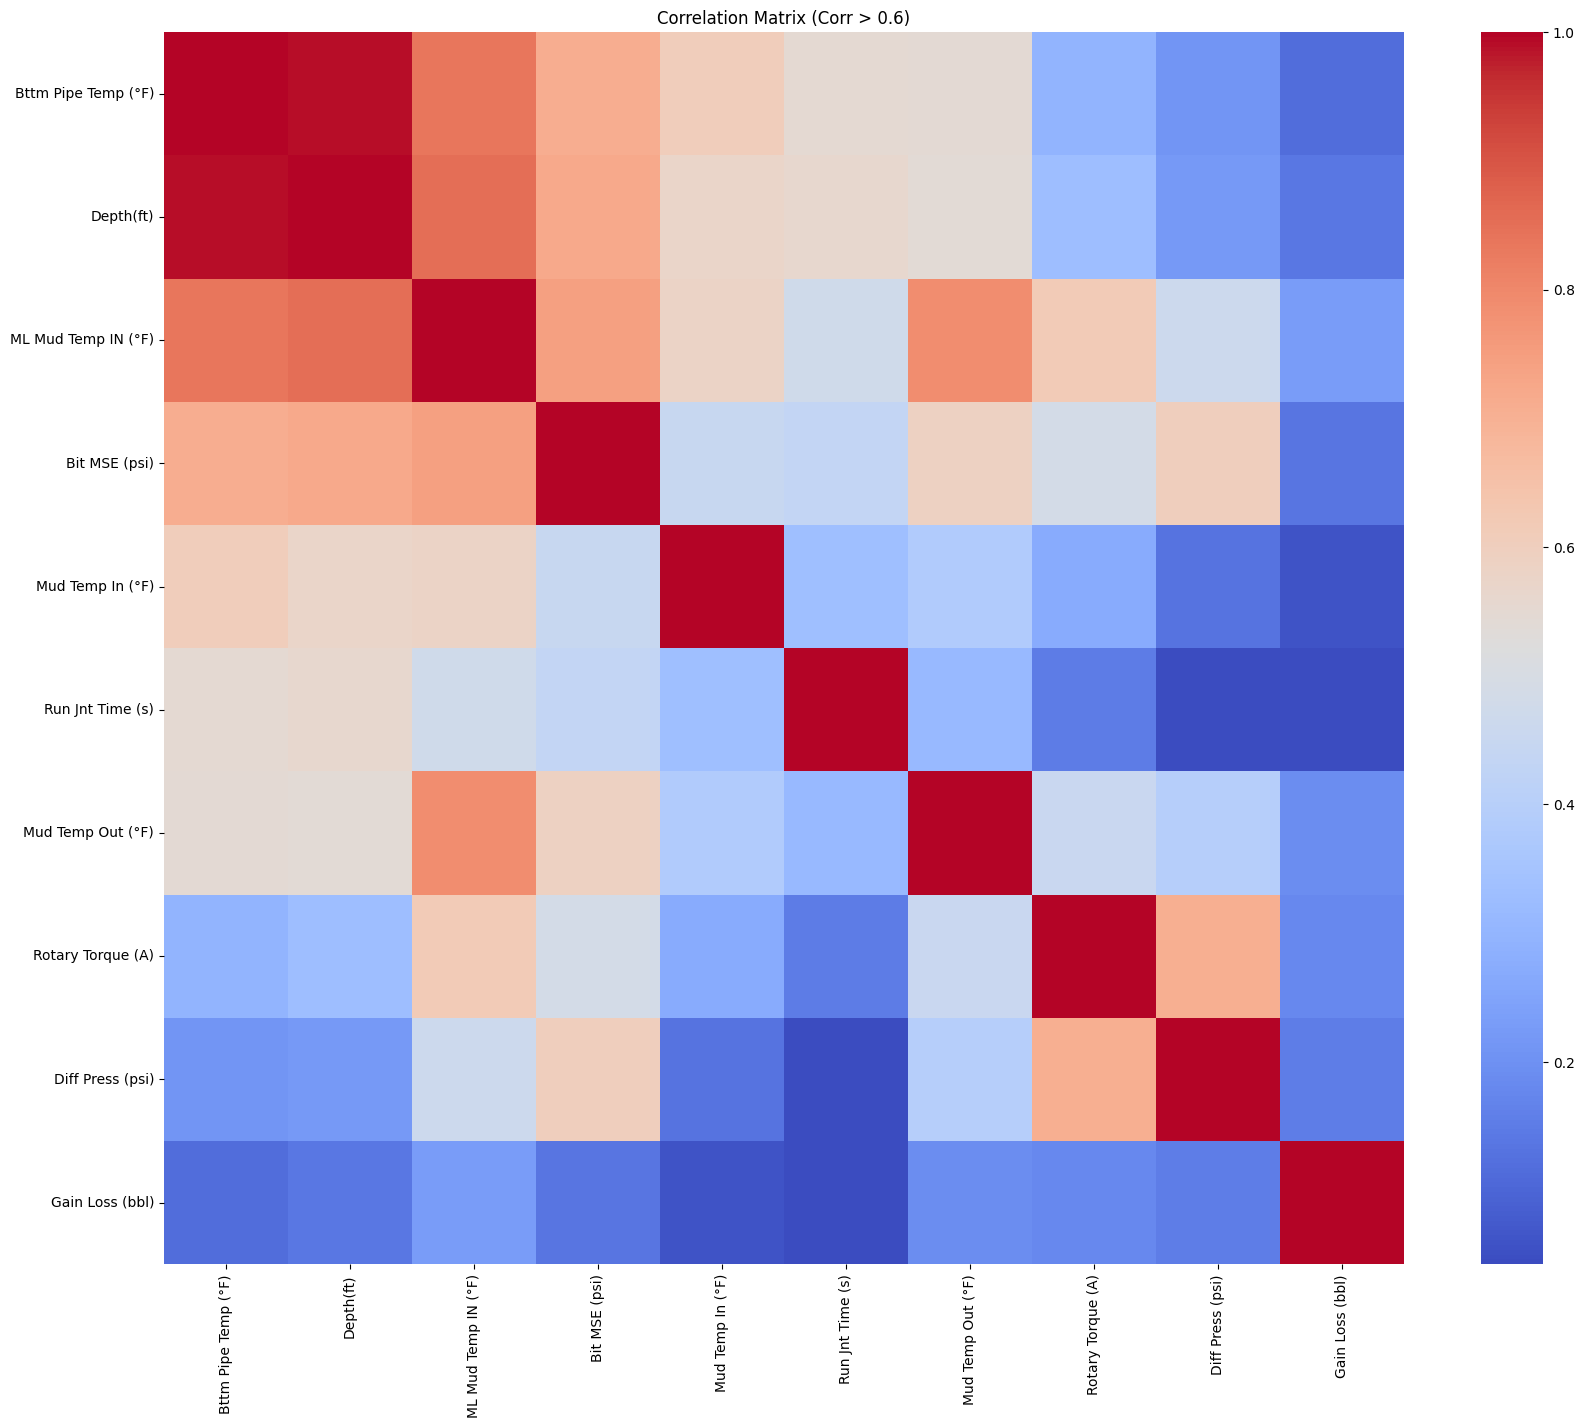

In [63]:
df3_clean[positive_corrs_cols].corr()

#plot the corr matrix
plt.figure(figsize=(20, 16))
sns.heatmap(df3_clean[positive_corrs_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix (Corr > 0.6)')
plt.show()

<BarContainer object of 10 artists>

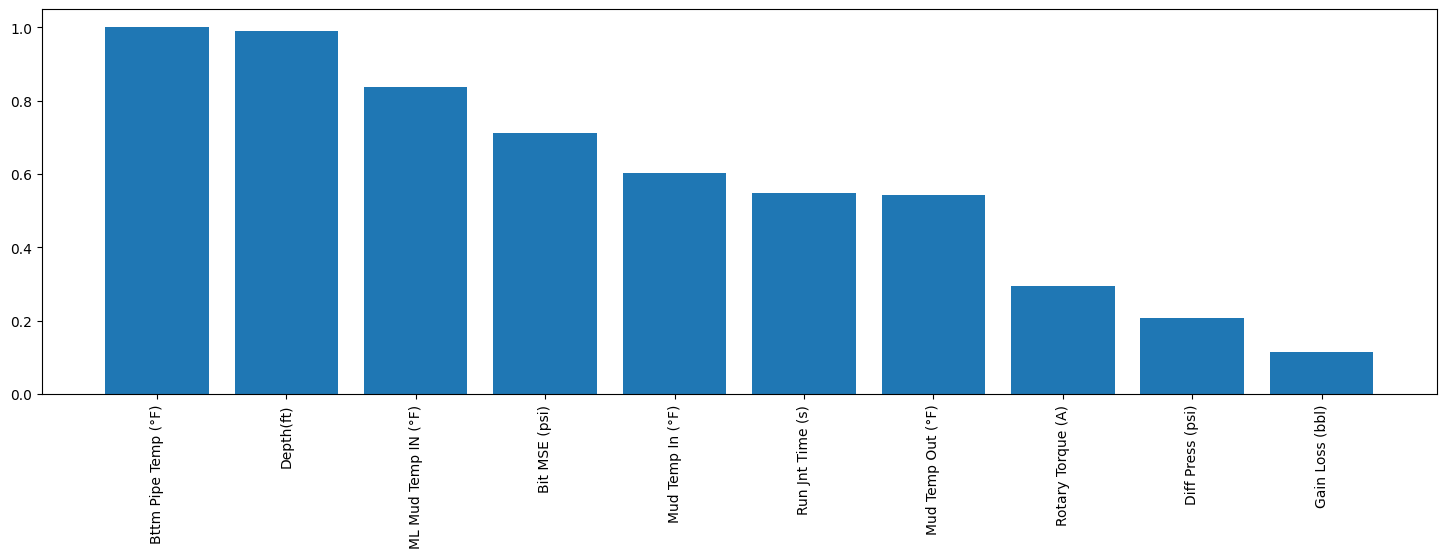

In [64]:
# rotate labels
plt.figure(figsize=(18, 5))
plt.xticks(rotation=90)
plt.bar(filtered_corr.index, filtered_corr.values)

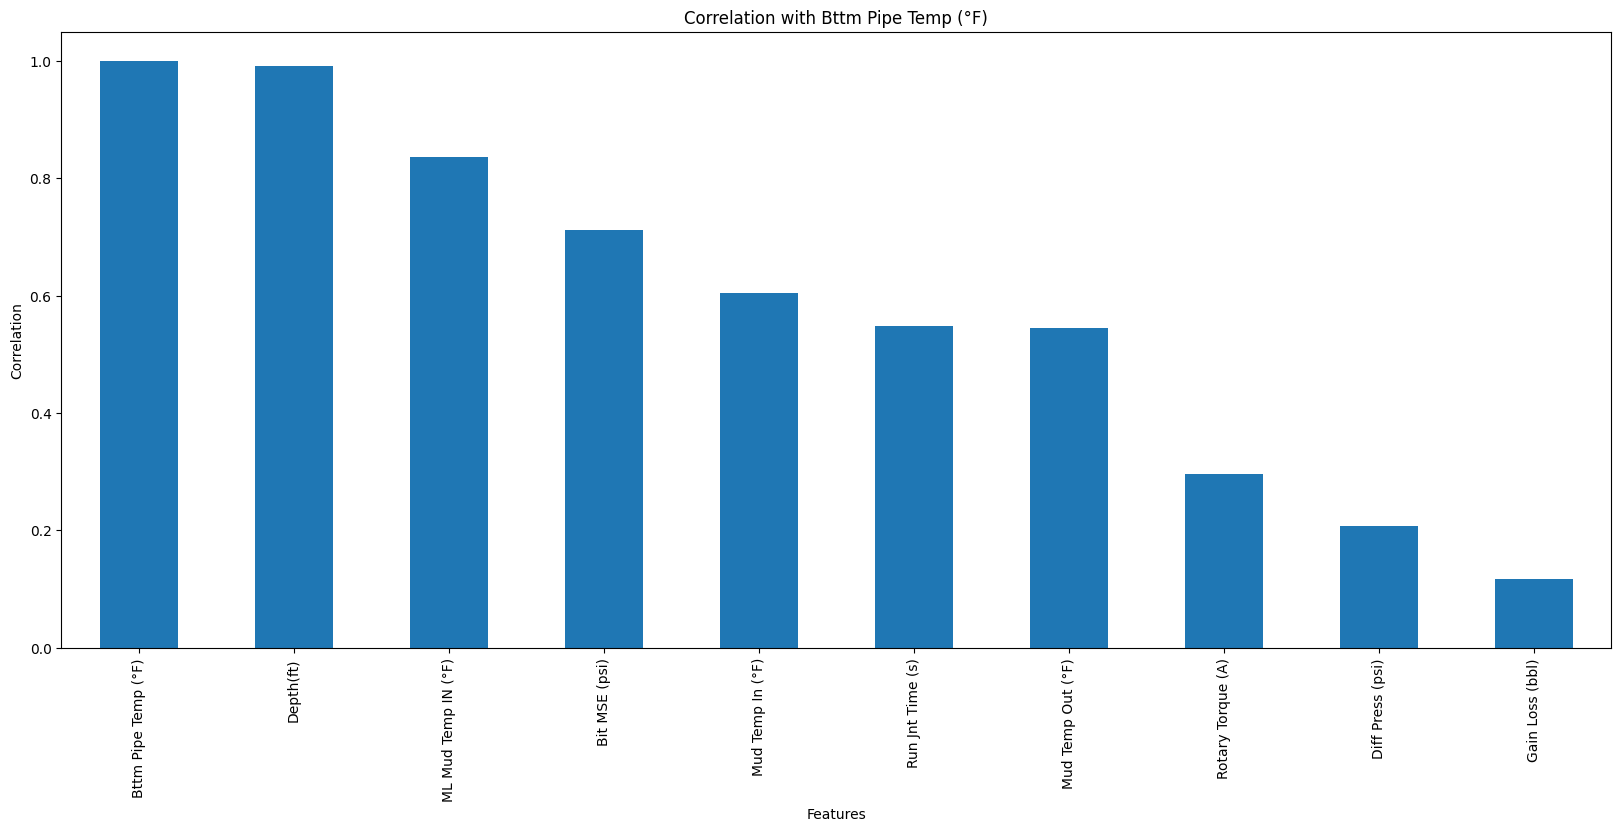

In [65]:
# draw a barchart for filtered_corr
plt.figure(figsize=(20, 8))
filtered_corr.plot(kind='bar')
plt.title('Correlation with Bttm Pipe Temp (°F)')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()


In [112]:
# display only more than 0.5 correlation
filtered_corr = filtered_corr[filtered_corr>0.9]

In [9]:
filtered_corr

Bttm Pipe Temp (°F)           1.000000
Pipe Length (ft)              0.991321
Depth(ft)                     0.990225
Bit Position (ft)             0.990225
Hole Depth (ft)               0.990225
Svy Depth (ft)                0.990157
Gamma Depth (ft)              0.990150
Bit Time (hr)                 0.954941
Time On Bottom (hr)           0.954941
Circulating Hrs (hr)          0.928037
Time On Job (hr)              0.880599
Hook Load (klb)               0.865380
Accum Trip Out (bbl)          0.816417
Strks - Acc Fill (strokes)    0.811670
ML Mud Temp IN (°F)           0.786532
Bit Weight (klb)              0.743150
AD WOB SP (klb)               0.644374
Mud Temp In (°F)              0.623595
Lst Jnt Time (s)              0.611531
Mud Temp Out (°F)             0.568082
Run Jnt Time (s)              0.566204
Name: Bttm Pipe Temp (°F), dtype: float64

In [8]:
def plot_vertical_profiles(dataframes, x_col, y_col, titles=None, figsize=(18, 5), invert_y=True):
    """
    Create multiple vertical line charts for comparing profiles across different datasets.
    
    Parameters:
    -----------
    dataframes : list of pandas.DataFrame
        List of dataframes containing the data to plot
    x_col : str
        Name of the column to use for x-axis values
    y_col : str
        Name of the column to use for y-axis values
    titles : list of str, optional
        List of titles for each subplot. If None, defaults to "Dataset 1", "Dataset 2", etc.
    figsize : tuple, optional
        Figure size (width, height) in inches
    invert_y : bool, optional
        Whether to invert the y-axis (useful for depth profiles)
        
    Returns:
    --------
    None: Displays the plot directly
    """
    import matplotlib.pyplot as plt
    
    # Clear any existing plots to prevent duplication
    plt.close('all')
    
    if titles is None:
        titles = [f"Dataset {i+1}" for i in range(len(dataframes))]
    
    # Create a new figure with a specific number
    fig, axes = plt.subplots(1, len(dataframes), figsize=figsize)
    
    # Handle the case where there's only one dataframe
    if len(dataframes) == 1:
        axes = [axes]
    
    # Plot on each axis
    for i, (df, title, ax) in enumerate(zip(dataframes, titles, axes)):
        ax.plot(df[x_col], df[y_col])
        if invert_y:
            ax.invert_yaxis()
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()
    
    # Not returning anything - display is handled inside the function

,Svy Azimuth (deg),Svy Inclination (deg),MSE Downhole (psi),MSE Total (psi),AD Delta-P SP (psi),Annular Velocity (ft/min),Mud Motor RPM (RPM),Pump SPM 1 (SPM),Flow In Rate (galUS/min),Pump SPM 2 (SPM),...,Top Drive Torque (kft·lbf),Total Rotations on DP (),Total Trip Volume (bbl),Trip Tank 1 (bbl),Trip Tank 2 (bbl),Trip Tank GL (bbl),WC Bit Weight (klb),WC Torque (ft·lbf),Washout Factor (),Water Pit (bbl)
Svy Azimuth (deg),1.000000,-0.062266,-0.350627,-0.412871,-0.209833,0.461573,0.461012,0.247940,0.461663,0.133242,...,-0.336927,-0.602052,0.522691,0.522285,0.525103,0.418788,0.633402,-0.327605,0.770176,-0.054138
Svy Inclination (deg),-0.062266,1.000000,0.119610,0.111316,-0.432616,-0.444969,-0.445412,-0.462323,-0.444464,0.099559,...,-0.401024,-0.167422,-0.146728,-0.146272,-0.152483,0.146093,-0.208575,-0.416804,-0.362576,0.054644
MSE Downhole (psi),-0.350627,0.119610,1.000000,0.974059,0.103147,-0.222998,-0.222870,-0.203440,-0.222935,-0.045048,...,0.114520,0.247237,-0.227836,-0.226802,-0.232852,-0.143436,-0.255865,0.109828,-0.364307,-0.006512
MSE Total (psi),-0.412871,0.111316,0.974059,1.000000,0.098007,-0.271146,-0.270953,-0.218135,-0.271141,-0.058604,...,0.163077,0.373627,-0.304297,-0.302738,-0.308465,-0.228420,-0.345040,0.158584,-0.419124,-0.011068
AD Delta-P SP (psi),-0.209833,-0.432616,0.103147,0.098007,1.000000,0.530288,0.530856,0.265298,0.530473,0.011163,...,0.805930,0.457560,0.342638,0.344229,0.341266,0.211274,0.234772,0.800632,0.127360,-0.015435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Trip Tank GL (bbl),0.418788,0.146093,-0.143436,-0.228420,0.211274,0.572520,0.571975,0.070734,0.573241,0.166347,...,0.003185,-0.420963,0.919526,0.922493,0.911694,1.000000,0.730239,-0.002534,0.468444,0.006461
WC Bit Weight (klb),0.633402,-0.208575,-0.255865,-0.345040,0.234772,0.732897,0.732531,0.231918,0.733026,0.169679,...,0.029278,-0.490242,0.821198,0.822845,0.820073,0.730239,1.000000,0.031868,0.764957,-0.006714
WC Torque (ft·lbf),-0.327605,-0.416804,0.109828,0.158584,0.800632,0.380520,0.381076,0.212110,0.380539,-0.010766,...,0.994835,0.660172,0.128170,0.130981,0.129337,-0.002534,0.031868,1.000000,-0.081119,-0.056935
Washout Factor (),0.770176,-0.362576,-0.364307,-0.419124,0.127360,0.775460,0.775233,0.379594,0.775242,0.176527,...,-0.091209,-0.408434,0.661943,0.663006,0.664397,0.468444,0.764957,-0.081119,1.000000,-0.032954


In [151]:
import pandas as pd
from tabulate import tabulate

df1 = df1_clean[filtered_corr.index]
df2 = df2_clean[filtered_corr.index]
df3 = df3_clean[filtered_corr.index]
# Assuming df1, df2, and df3 are your DataFrames
summary_df1 = df1.describe()
summary_df2 = df2.describe()
summary_df3 = df3.describe()

# Convert summary statistics to Markdown tables
summary_md_df1 = tabulate(summary_df1, headers='keys', tablefmt='pipe')
summary_md_df2 = tabulate(summary_df2, headers='keys', tablefmt='pipe')
summary_md_df3 = tabulate(summary_df3, headers='keys', tablefmt='pipe')

# Print Markdown tables
print("Summary Statistics for df1:")
print(summary_md_df1)
print("\nSummary Statistics for df2:")
print(summary_md_df2)
print("\nSummary Statistics for df3:")
print(summary_md_df3)

Summary Statistics for df1:
|       |   Bttm Pipe Temp (°F) |   Pipe Length (ft) |   Depth(ft) |   Bit Position (ft) |   Hole Depth (ft) |   Svy Depth (ft) |   Gamma Depth (ft) |   Bit Time (hr) |   Time On Bottom (hr) |   Circulating Hrs (hr) |
|:------|----------------------:|-------------------:|------------:|--------------------:|------------------:|-----------------:|-------------------:|----------------:|----------------------:|-----------------------:|
| count |              7800     |            7800    |     7800    |             7800    |           7800    |          7800    |            7800    |       7800      |             7800      |              7800      |
| mean  |               133.12  |            2945.51 |     4070.37 |             4071.2  |           4071.2  |          3958.91 |            4010.65 |         23.0861 |               23.0861 |                37.4025 |
| std   |                18.364 |            2121.89 |     2278    |             2278.07 |          

In [6]:
df = pd.read_csv('../data/phase_1/training_dataset_3_inliers.csv')

In [9]:
X = df
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


                  Feature          VIF
0       Svy Azimuth (deg)    79.584300
1   Svy Inclination (deg)    24.367814
2      MSE Downhole (psi)   140.851277
3         MSE Total (psi)   150.044353
4     AD Delta-P SP (psi)   126.231563
..                    ...          ...
79     Trip Tank GL (bbl)  2002.485080
80    WC Bit Weight (klb)  6366.480766
81     WC Torque (ft·lbf)   447.668116
82      Washout Factor ()  1458.787855
83        Water Pit (bbl)    35.148776

[84 rows x 2 columns]


In [8]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

# Creating a dataset with high multicollinearity
np.random.seed(42)
X1 = np.random.rand(100)
X2 = X1 * 0.95 + np.random.rand(100) * 0.05  # X2 is highly correlated with X1

# Put into a DataFrame
data = pd.DataFrame({'X1': X1, 'X2': X2})

# Add constant for the intercept
X = add_constant(data)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


  Feature         VIF
0   const    6.628110
1      X1  371.983231
2      X2  371.983231


In [64]:
# codebase/data/phase_1/training_dataset_3_inliers.csv
df1 = pd.read_csv('../data/phase_1/training_dataset_1_inliers.csv')
df2 = pd.read_csv('../data/phase_1/training_dataset_2_inliers.csv')
df3 = pd.read_csv('../data/phase_1/training_dataset_3_inliers.csv')

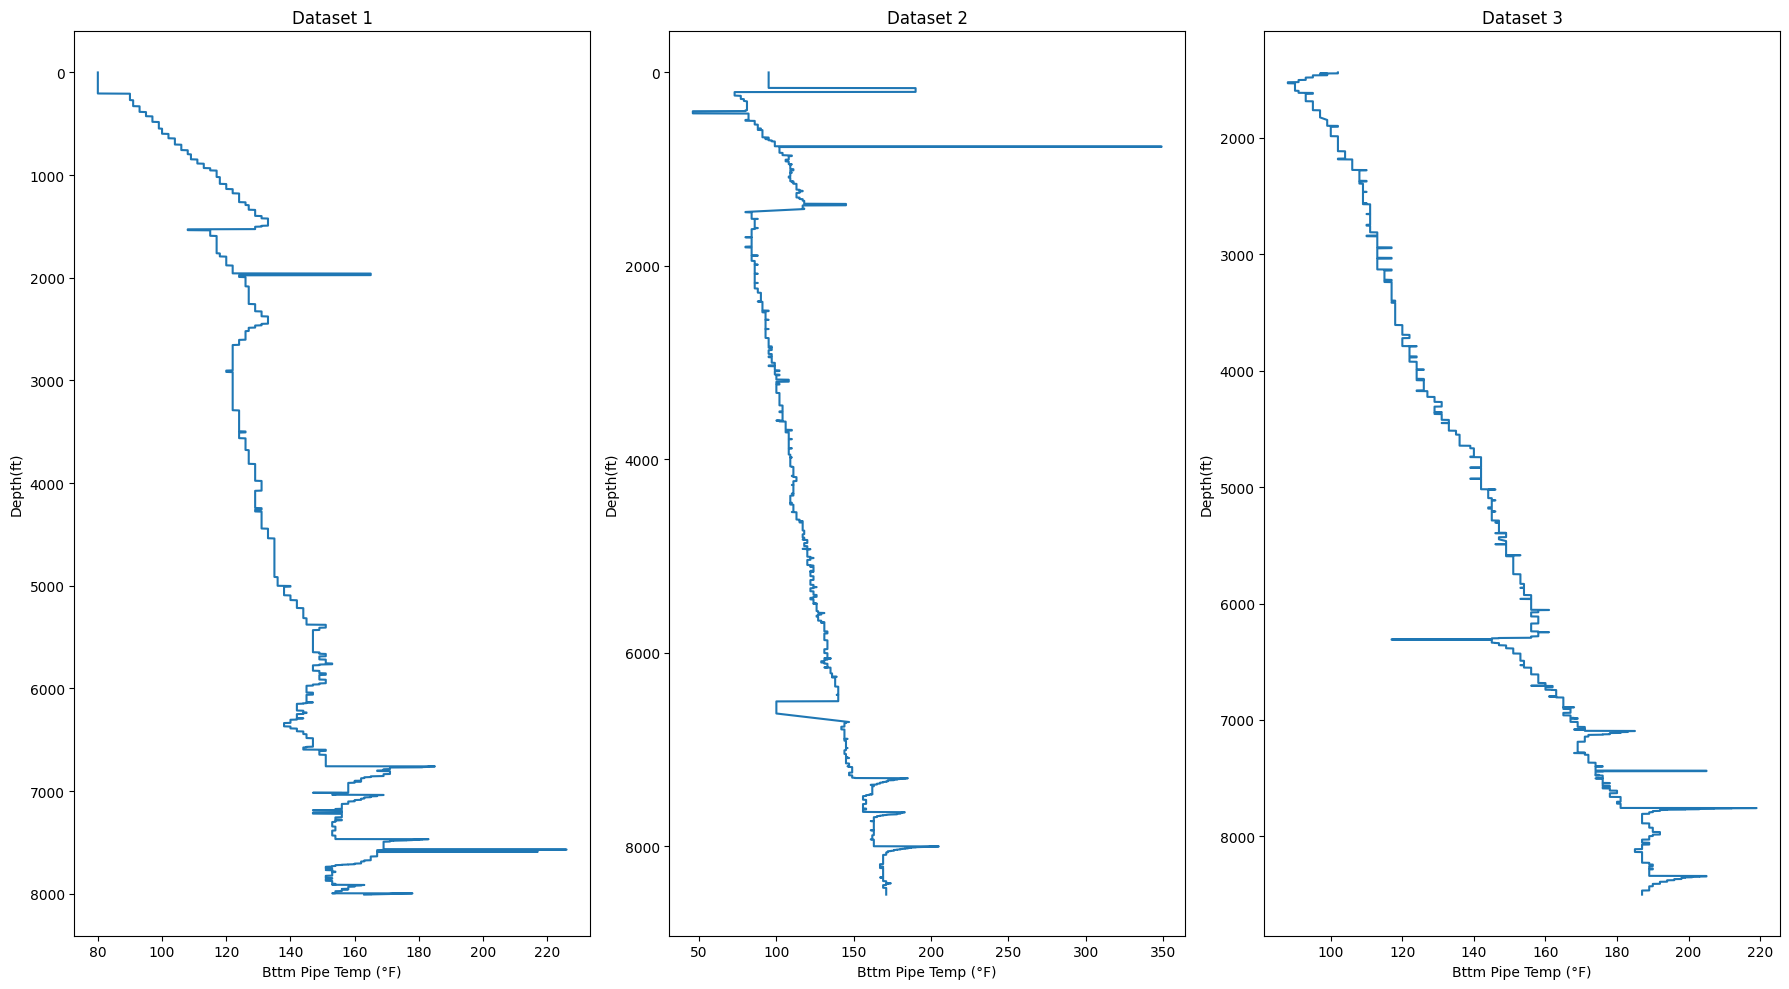

In [24]:
plot_vertical_profiles([df1, df2, df3], 'Bttm Pipe Temp (°F)', 'Depth(ft)', titles=['Dataset 1', 'Dataset 2', 'Dataset 3'], figsize=(18, 10))



In [4]:
df_test = pd.read_csv('../data/phase_1/Test_dataset_1.csv')

In [121]:
df = pd.concat([df2_clean], axis=0)


df = df[selected_columns]

In [120]:
selected_columns = ['Bttm Pipe Temp (°F)',
 'Depth(ft)',
 'Bit MSE (psi)',
 'Mud Temp Out (°F)',
 'ML Mud Temp IN (°F)',
 'Mud Temp In (°F)',
 'Run Jnt Time (s)']

Epoch 1/100


/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 9609.3896 - val_loss: 12806.2939
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7095.0898 - val_loss: 10938.3926
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5684.4976 - val_loss: 9371.2920
Epoch 4/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4664.2383 - val_loss: 8021.0098
Epoch 5/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3757.4373 - val_loss: 6852.9941
Epoch 6/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3059.7988 - val_loss: 5845.8428
Epoch 7/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2366.4670 - val_loss: 4981.1416
Epoch 8/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1950.8164 - val_loss: 4241.2119
Epoch 9/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1541.8385 - val_loss: 3614.1860
Epoch 10/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1207.0648 - val_loss: 3082.8328
Epoch 11/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 943.5776 - va

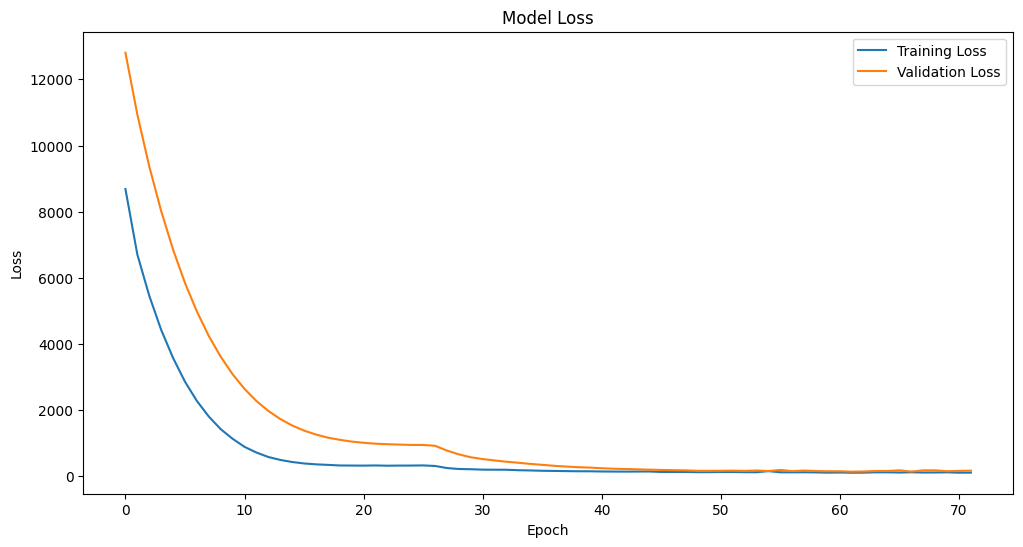

207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In-sample MSE: 64.667
In-sample R2: 0.824
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Out-of-sample MSE: 1081.022
Out-of-sample R2: -8.655
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/5

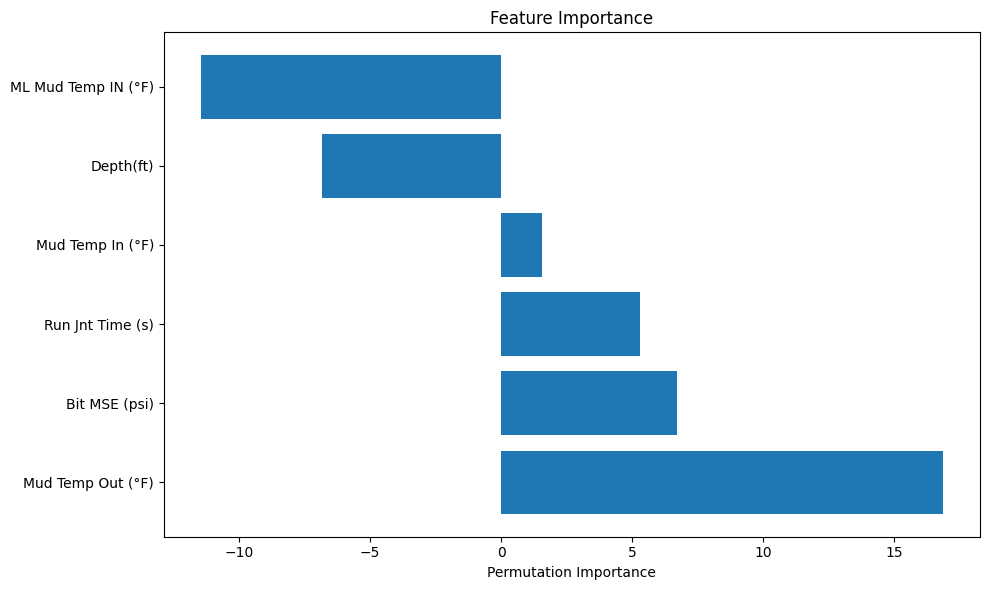

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Define X and y from your dataframe
X = df.drop(columns=['Bttm Pipe Temp (°F)'])
y = df['Bttm Pipe Temp (°F)']

# Calculate the split point at 80% of the data
split_point = int(len(X) * 0.8)

# Split the data
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# Scale the data
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# For LSTM, we need to reshape the data to [samples, time steps, features]
# Assuming each row is a time step, we'll create sequences of 10 time steps
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Create sequences for training and testing
time_steps = 10
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, time_steps)

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_steps, X_train.shape[1])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Plot the training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Evaluate on training data (in-sample)
y_pred_train = model.predict(X_train_seq)
train_mse = mean_squared_error(y_train_seq, y_pred_train)
# Calculate R2 manually for train data
ss_total = np.sum((y_train_seq - np.mean(y_train_seq)) ** 2)
ss_residual = np.sum((y_train_seq - y_pred_train.flatten()) ** 2)
train_r2 = 1 - (ss_residual / ss_total)

print(f'\nIn-sample MSE: {train_mse:.3f}')
print(f'In-sample R2: {train_r2:.3f}')

# Evaluate on test data (out-of-sample)
y_pred_test = model.predict(X_test_seq)
test_mse = mean_squared_error(y_test_seq, y_pred_test)
# Calculate R2 manually for test data
ss_total = np.sum((y_test_seq - np.mean(y_test_seq)) ** 2)
ss_residual = np.sum((y_test_seq - y_pred_test.flatten()) ** 2)
test_r2 = 1 - (ss_residual / ss_total)

print(f'\nOut-of-sample MSE: {test_mse:.3f}')
print(f'Out-of-sample R2: {test_r2:.3f}')

# Feature importance for LSTM is not as straightforward as for linear models
# We can use a permutation importance approach
def permutation_importance(model, X, y, n_repeats=10):
    baseline_mse = mean_squared_error(y, model.predict(X).flatten())
    importances = []
    
    for i in range(X.shape[2]):  # Loop through features
        feature_importances = []
        
        for _ in range(n_repeats):
            # Create a copy of X with the i-th feature permuted
            X_permuted = X.copy()
            X_permuted[:, :, i] = np.random.permutation(X_permuted[:, :, i])
            
            # Predict with permuted feature and calculate loss
            permuted_mse = mean_squared_error(y, model.predict(X_permuted).flatten())
            
            # Importance is how much worse the model performs when feature is permuted
            importance = permuted_mse - baseline_mse
            feature_importances.append(importance)
        
        importances.append(np.mean(feature_importances))
    
    return np.array(importances)

# Calculate feature importance (this will take some time)
feature_names = X_train.columns
feature_importance = permutation_importance(model, X_test_seq, y_test_seq)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False)

# Print feature importances
print("\nFeature Importances (higher value = more important):")
for i, row in importance_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [27]:
import numpy as np

In [123]:
# train the model using ridge regression 
from sklearn.linear_model import RidgeCV
ridge = RidgeCV(alphas=np.logspace(-3, 3, 7), store_cv_values=True)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
print("Ridge Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

# train the model using lasso regression
from sklearn.linear_model import LassoCV
lasso = LassoCV(alphas=np.logspace(-3, 3, 7), cv=5)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
print("Lasso Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

# train the model using elastic net regression
from sklearn.linear_model import ElasticNetCV
elastic_net = ElasticNetCV(alphas=np.logspace(-3, 3, 7), l1_ratio=0.5, cv=5)
elastic_net.fit(X_train_scaled, y_train)
y_pred = elastic_net.predict(X_test_scaled)
print("Elastic Net Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

# train the model using decision tree regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt = DecisionTreeRegressor()
grid_search = GridSearchCV(dt, param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
y_pred = grid_search.predict(X_test_scaled)
print("Decision Tree Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))




/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Ridge Regression
MSE:  410.88102736206577
R2:  -2.636263998150562
Lasso Regression
MSE:  441.0929338878598
R2:  -2.9036369375158735
Elastic Net Regression
MSE:  474.25929236772237
R2:  -3.1971565387112983
Decision Tree Regression
MSE:  502.37855392540087
R2:  -3.4460097386587965


In [36]:
# train the model using random forest regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}
rf = RandomForestRegressor()
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=100, cv=5)
random_search.fit(X_train_scaled, y_train)
y_pred = random_search.predict(X_test_scaled)
print("Random Forest Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))





Random Forest Regression
MSE:  8.786720314111196
R2:  0.9877381061298763


In [ ]:
# drop temp from selected_cols



In [45]:
selected_cols

['Depth(ft)',
 'Bit Time (hr)',
 'Time On Bottom (hr)',
 'Hook Load (klb)',
 'Strks - Acc Fill (strokes)',
 'ML Mud Temp IN (°F)',
 'Bit Weight (klb)',
 'Mud Temp In (°F)',
 'Lst Jnt Time (s)',
 'Mud Temp Out (°F)',
 'Run Jnt Time (s)',
 'Total Rotations on DP ()',
 'MSE Total (psi)',
 'Bit MSE (psi)',
 'Gain Loss (bbl)',
 'Rotary Torque (A)',
 'Diff Press (psi)']

In [53]:
# read three datasets and subset them using selected_cols, datasets are Test_dataset_1,2,3
df1_test = pd.read_csv('../data/phase_1/Test_dataset_1.csv')[selected_cols]
df2_test = pd.read_csv('../data/phase_1/Test_dataset_2.csv')[selected_cols]
df3_test = pd.read_csv('../data/phase_1/Test_dataset_3.csv')[selected_cols]



In [54]:
ridge.predict(df1_test)

/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RidgeCV was fitted without feature names
  warnings.warn(


array([6250424.03786175, 6250997.8467268 , 6252318.38656307,
       6253209.40518558, 6253774.14110254, 6252200.97216314,
       6252124.289867  , 6248500.21052101, 6249106.997608  ,
       6248991.73009476, 6249026.2749578 , 6247578.86549329,
       6245902.76489558, 6245884.1389593 , 6246482.65095297,
       6245303.72389185, 6247857.25277462, 6246366.0259339 ,
       6246632.40455435, 6250215.98577557, 6243762.82480728,
       6243343.98441639, 6245231.72178325, 6243940.21150221,
       6242336.38825574, 6242953.28900466, 6243487.18615549,
       6243801.04703481, 6242931.90515626, 6245474.78416168,
       6241617.36934273, 6242918.42631606, 6250717.28430854,
       6240032.16996378, 6243736.54170737, 6241227.89345801,
       6242652.51214184, 6246207.24249497, 6244817.20008024,
       6248376.60209664, 6246989.03865866, 6246789.45243196,
       6241871.84772985, 6245338.25682402, 6239819.38496959,
       6241620.30854854, 6241531.70635693, 6239819.28189087,
       6242127.77326728,

In [41]:
# predict using the models created above
# predict using ridge regression
y_pred = ridge.predict(df1_test)
df1_test['Bttm Pipe Temp (°F)'] = y_pred

# do it for df2_test and df3_test
y_pred = ridge.predict(df2_test)
df2_test['Bttm Pipe Temp (°F)'] = y_pred
y_pred = ridge.predict(df3_test)
df3_test['Bttm Pipe Temp (°F)'] = y_pred




/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RidgeCV was fitted without feature names
  warnings.warn(
/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RidgeCV was fitted without feature names
  warnings.warn(
/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RidgeCV was fitted without feature names
  warnings.warn(


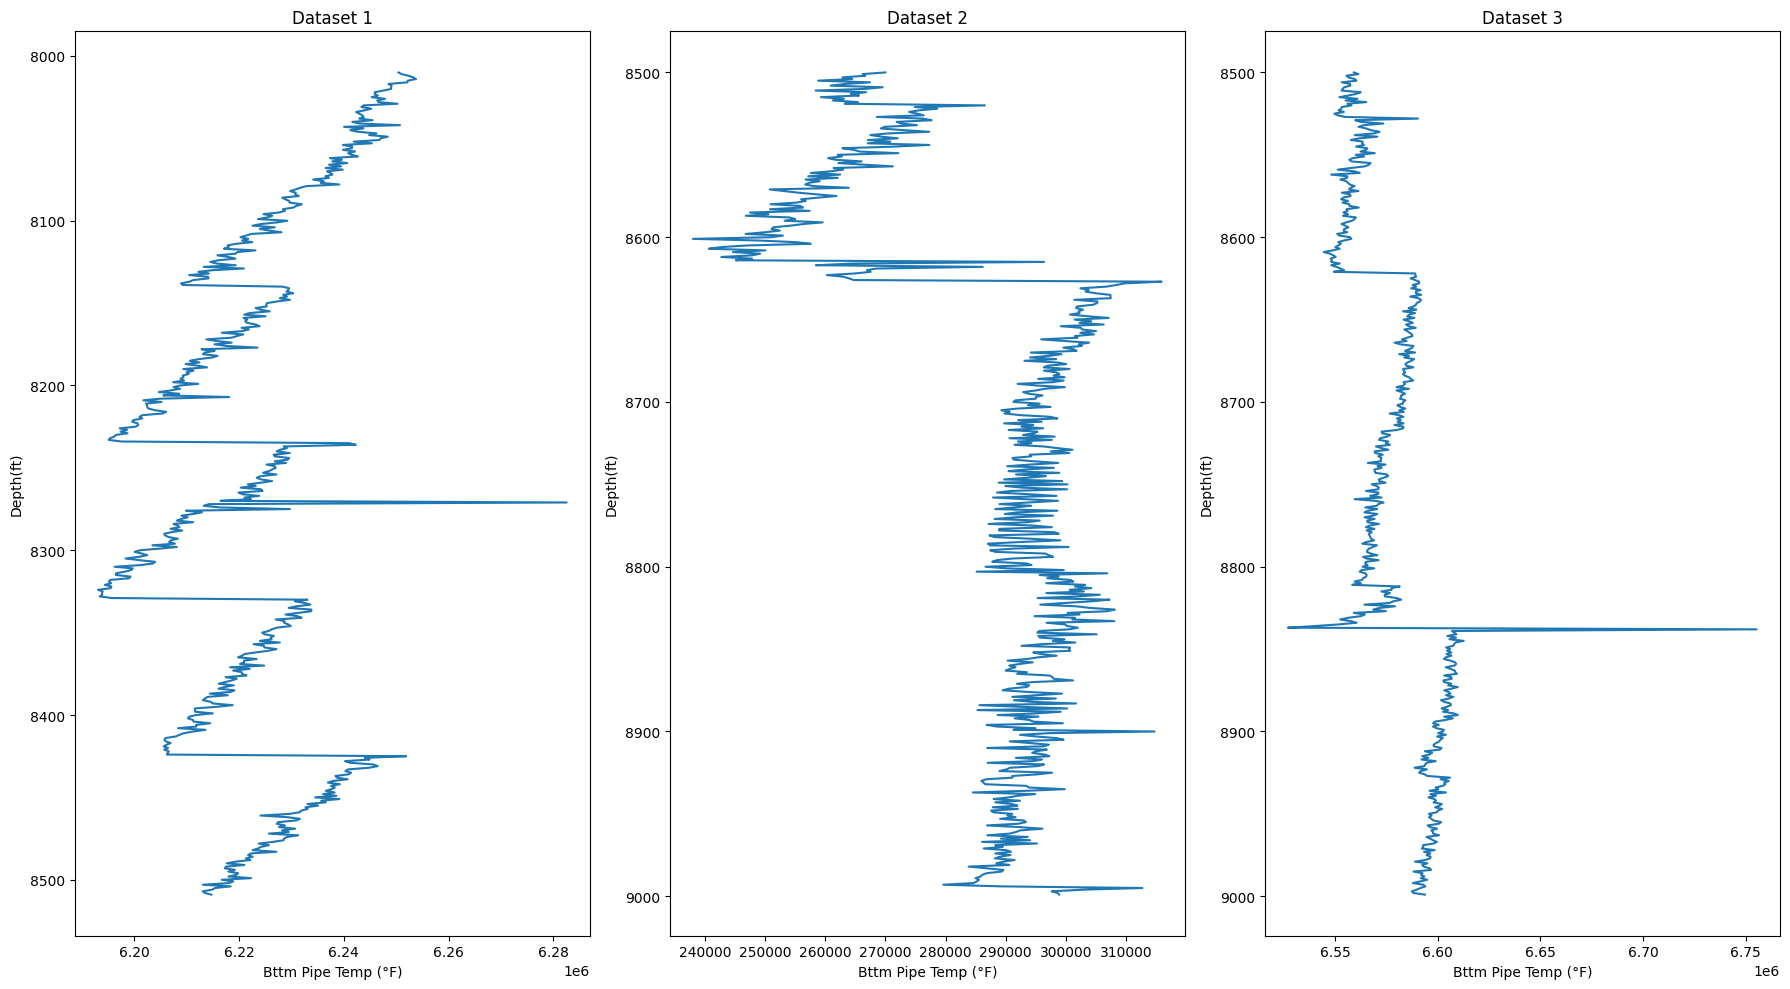

In [43]:
plot_vertical_profiles([df1_test, df2_test, df3_test], 'Bttm Pipe Temp (°F)', 'Depth(ft)', titles=['Dataset 1', 'Dataset 2', 'Dataset 3'], figsize=(18, 10))

In [128]:
def predict_temperature_with_automl(df, target_col='temperature', id_cols=None, 
                                   test_size=0.2, time_budget=3600, metric='rmse',
                                   save_path=None):
    """
    Train an AutoML model to predict temperature on sequential data.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing features and target variable, assumed to be in chronological order
    target_col : str, default 'temperature'
        Name of the temperature column to predict
    id_cols : list or None, default None
        List of columns to exclude from features (IDs, timestamps, etc.)
    test_size : float, default 0.2
        Proportion of data to use for testing (last portion of the data)
    time_budget : int, default 3600
        Time budget for AutoML in seconds (default: 1 hour)
    metric : str, default 'rmse'
        Evaluation metric ('rmse', 'mae', 'r2', etc.)
    save_path : str or None, default None
        Path to save the trained model. If None, model won't be saved.
        
    Returns:
    --------
    dict : Dictionary containing model, predictions, and evaluation metrics
    """
    import pandas as pd
    import numpy as np
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import pickle
    import warnings
    warnings.filterwarnings('ignore')
    
    # Check if target column exists in the dataframe
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in the dataframe")
    
    # Prepare data - remove ID columns and target from features
    if id_cols is None:
        id_cols = []
    
    # Create feature and target variables
    X = df.drop([target_col] + id_cols, axis=1)
    y = df[target_col]
    
    # Calculate the split index for chronological split (first 80%, last 20%)
    split_idx = int(len(df) * (1 - test_size))
    
    # Split data chronologically - train on first 80%, test on last 20%
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
    print(f"Training on data from index 0 to {split_idx-1}")
    print(f"Testing on data from index {split_idx} to {len(df)-1}")
    
    # Try to use AutoML frameworks
    try:
        # First try using H2O AutoML if available
        import h2o
        from h2o.automl import H2OAutoML
        
        print("Using H2O AutoML framework...")
        
        # Initialize H2O
        h2o.init()
        
        # Convert data to H2O frames
        train_h2o = h2o.H2OFrame(pd.concat([X_train, y_train], axis=1))
        test_h2o = h2o.H2OFrame(pd.concat([X_test, y_test], axis=1))
        
        # Identify predictors and response
        x = X_train.columns.tolist()
        y = target_col
        
        # Run AutoML
        aml = H2OAutoML(max_runtime_secs=time_budget, seed=42)
        aml.train(x=x, y=y, training_frame=train_h2o)
        
        # Get the best model
        best_model = aml.leader
        
        # Make predictions
        preds_h2o = best_model.predict(test_h2o)
        predictions = preds_h2o.as_data_frame().values.flatten()
        
        # Get model performance
        perf = best_model.model_performance(test_h2o)
        
        # Save model if path is provided
        if save_path:
            model_path = h2o.save_model(model=best_model, path=save_path)
            print(f"Model saved to {model_path}")
        
        # Clean up H2O
        h2o.remove_all()
        
        # Prepare results
        framework_used = 'h2o'
        model_info = str(best_model)
        leaderboard = aml.leaderboard.as_data_frame()
        
    except (ImportError, Exception) as h2o_error:
        print(f"H2O AutoML not available or failed: {h2o_error}")
        
        try:
            # Try using AutoGluon if available
            from autogluon.tabular import TabularPredictor
            
            print("Using AutoGluon framework...")
            
            # Prepare training data with target
            train_data = pd.concat([X_train, y_train], axis=1)
            
            # Initialize and train predictor
            predictor = TabularPredictor(
                label=target_col,
                eval_metric=metric,
                problem_type='regression'
            ).fit(
                train_data,
                time_limit=time_budget
            )
            
            # Make predictions
            predictions = predictor.predict(X_test).values
            
            # Get model performance
            leaderboard = predictor.leaderboard()
            
            # Save model if path is provided
            if save_path:
                predictor.save(save_path)
                print(f"Model saved to {save_path}")
            
            # Prepare results
            framework_used = 'autogluon'
            model_info = str(predictor.get_model_best())
            best_model = predictor
            
        except (ImportError, Exception) as ag_error:
            print(f"AutoGluon not available or failed: {ag_error}")
            
            try:
                # Try using TPOT if available
                from tpot import TPOTRegressor
                
                print("Using TPOT AutoML framework...")
                
                # Initialize and train TPOT
                tpot = TPOTRegressor(
                    generations=5,
                    population_size=50,
                    verbosity=2,
                    random_state=42,
                    max_time_mins=int(time_budget/60),
                    n_jobs=-1
                )
                
                tpot.fit(X_train, y_train)
                
                # Make predictions
                predictions = tpot.predict(X_test)
                
                # Save model if path is provided
                if save_path:
                    tpot.export(f"{save_path}_pipeline.py")
                    print(f"Model pipeline saved to {save_path}_pipeline.py")
                    
                    with open(f"{save_path}.pkl", 'wb') as f:
                        pickle.dump(tpot, f)
                    print(f"Model saved to {save_path}.pkl")
                
                # Prepare results
                framework_used = 'tpot'
                model_info = tpot.fitted_pipeline_
                best_model = tpot
                leaderboard = None
                
            except (ImportError, Exception) as tpot_error:
                print(f"TPOT not available or failed: {tpot_error}")
                
                # Fallback to scikit-learn's RandomForestRegressor
                from sklearn.ensemble import RandomForestRegressor
                
                print("Falling back to scikit-learn RandomForestRegressor...")
                
                # Train a simple model
                model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
                model.fit(X_train, y_train)
                
                # Make predictions
                predictions = model.predict(X_test)
                
                # Save model if path is provided
                if save_path:
                    with open(f"{save_path}.pkl", 'wb') as f:
                        pickle.dump(model, f)
                    print(f"Model saved to {save_path}.pkl")
                
                # Prepare results
                framework_used = 'sklearn'
                model_info = str(model)
                best_model = model
                leaderboard = None
    
    # Calculate evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    print(f"\nModel Training Complete using {framework_used}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    # Create results dictionary
    results = {
        'model': best_model,
        'framework': framework_used,
        'model_info': model_info,
        'predictions': predictions,
        'true_values': y_test.values,
        'metrics': {
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        },
        'feature_importances': get_feature_importance(best_model, X_train.columns, framework_used),
        'leaderboard': leaderboard
    }
    
    return results

In [125]:
selected_columns

['Bttm Pipe Temp (°F)',
 'Depth(ft)',
 'Bit MSE (psi)',
 'Mud Temp Out (°F)',
 'ML Mud Temp IN (°F)',
 'Mud Temp In (°F)',
 'Run Jnt Time (s)']

Training set shape: (5596, 83), Test set shape: (1399, 83)
Training on data from index 0 to 5595
Testing on data from index 5596 to 6994
Using H2O AutoML framework...
Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,44 mins 51 secs
H2O_cluster_timezone:,America/Chicago
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,4 months
H2O_cluster_name:,H2O_from_python_atheer_w0obos
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,21.82 Gb
H2O_cluster_total_cores:,40
H2O_cluster_allowed_cores:,40
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
00:10:46.989: _train param, Dropping bad and constant columns: [Casing Pressure (psi), Accum Trip In (bbl)]

██
00:10:59.728: _train param, Dropping bad and constant columns: [Casing Pressure (psi), Accum Trip In (bbl)]
00:11:00.242: _train param, Dropping bad and constant columns: [Casing Pressure (psi), Accum Trip In (bbl)]

███
00:11:44.330: _train param, Dropping unused columns: [Casing Pressure (psi), Accum Trip In (bbl)]
00:11:45.736: _train param, Dropping bad and constant columns: [Casing Pressure (psi), Accum Trip In (bbl)]


00:11:55.542: _train param, Dropping bad and constant columns: [Casing Pressure (psi), Accum Trip In (bbl)]

██
00:12:07.114: _train param, Dropping bad and constant columns: [Casing Pressure (psi), Accum Trip In (bbl)]

█
00:12:15.556: _train param,

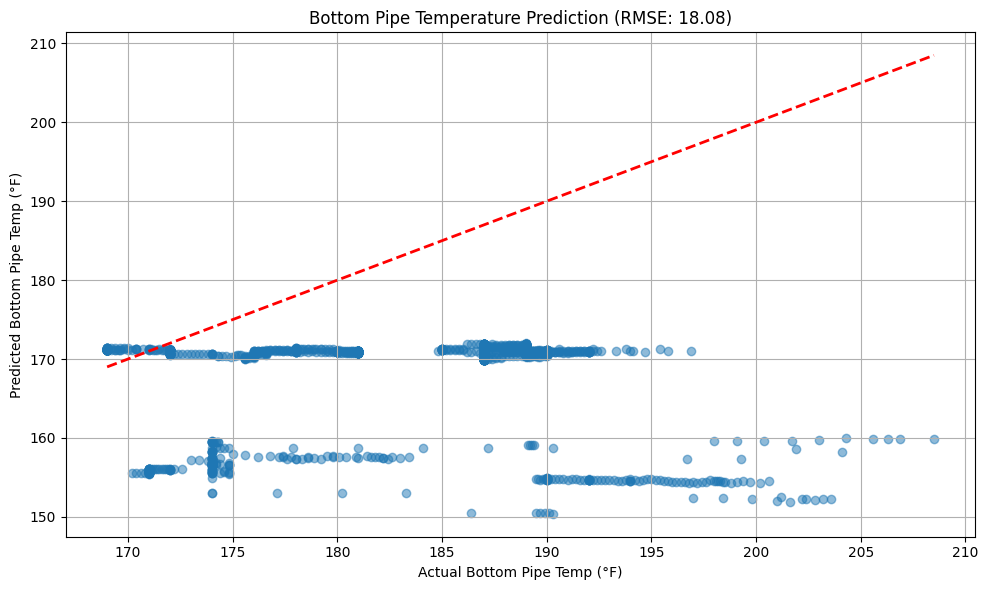

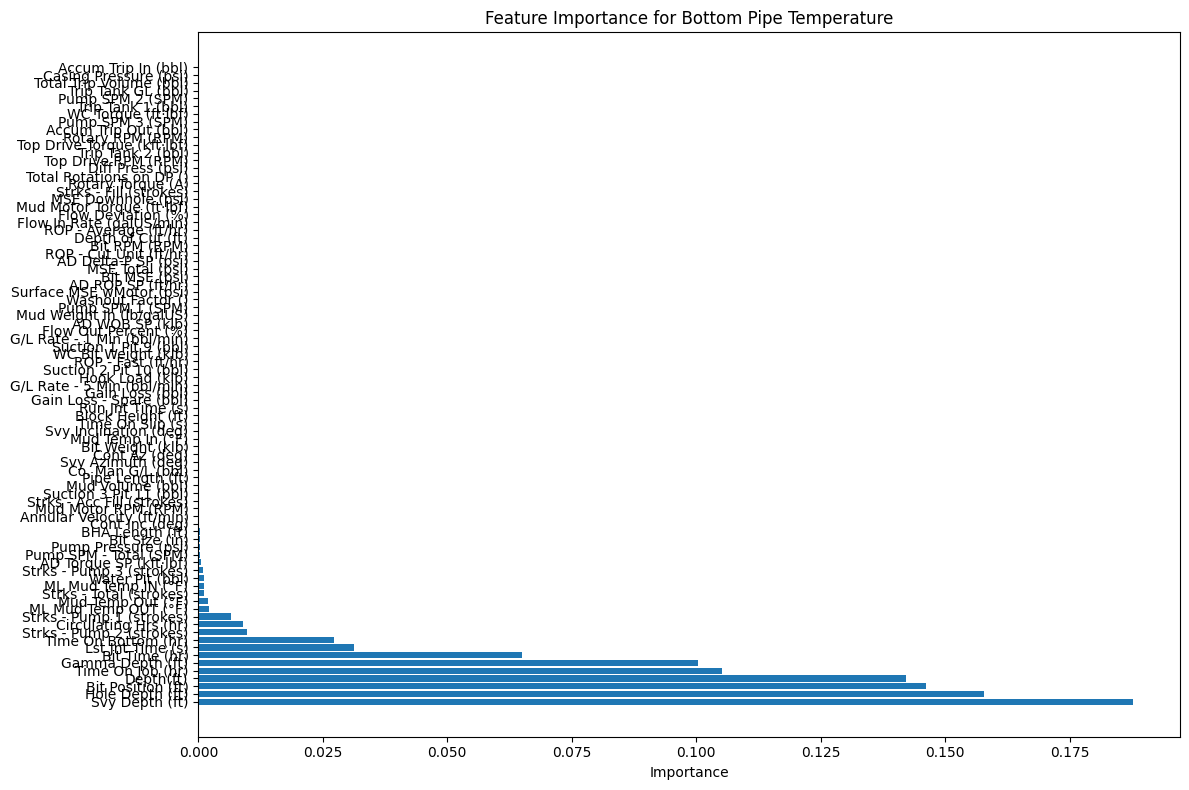

In [129]:
# Define all columns in the dataset
all_columns = [
    'Bttm Pipe Temp (°F)',
    'Depth(ft)',
    'Bit MSE (psi)',
    'Mud Temp Out (°F)',
    'ML Mud Temp IN (°F)',
    'Mud Temp In (°F)',
    'Run Jnt Time (s)'
]

# First, make sure your data is prepared (clean, no missing values, etc.)
# Then train the model
results = predict_temperature_with_automl(
    df=df3_clean,                       # Your cleaned dataframe
    target_col='Bttm Pipe Temp (°F)',   # Column to predict
    id_cols=[],                         # No ID columns to exclude
    time_budget=1800,                   # 30 minutes
    save_path='models/bottom_pipe_temp_model'  # Path to save the model
)

# Access the results
model = results['model']
predictions = results['predictions']
true_values = results['true_values']
rmse = results['metrics']['rmse']
feature_importance = results['feature_importances']

# Visualize the predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(true_values, predictions, alpha=0.5)
plt.plot([true_values.min(), true_values.max()], 
         [true_values.min(), true_values.max()], 
         'r--', lw=2)
plt.xlabel('Actual Bottom Pipe Temp (°F)')
plt.ylabel('Predicted Bottom Pipe Temp (°F)')
plt.title(f'Bottom Pipe Temperature Prediction (RMSE: {rmse:.2f})')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot feature importance if available
if feature_importance is not None:
    plt.figure(figsize=(12, 8))
    if isinstance(feature_importance, pd.DataFrame):
        # Sort by importance
        top_features = feature_importance.sort_values('importance', ascending=False)
        plt.barh(top_features['feature'], top_features['importance'])
    plt.title('Feature Importance for Bottom Pipe Temperature')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()